# 📦 Cell 1 — Install Dependencies

In [1]:
# 🔥 CLEAN ENV (VERY IMPORTANT)
!pip uninstall -y transformers huggingface_hub tokenizers accelerate -q

# ✅ INSTALL PERFECTLY MATCHED VERSIONS
!pip install -q \
transformers==4.37.2 \
huggingface_hub==0.20.3 \
tokenizers==0.15.2 \
accelerate==0.25.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 99.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 330.1/330.1 kB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 92.7 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.7/265.7 kB 18.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
datasets 4.8.3 requires huggingface-hub<2.0,>=0.25.0, but you have huggingface-hub 0.20.3 which is incompatible.
peft 0.18.1 requires huggingface_hub>=0.25.0, but you have huggingface-hub 0.20.3 which is incompatible.
sentence-transformers 5.2.3 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.37.2 which is incompatible.
diffusers 0.36.0 requires huggingface-hub<2.0,>=0.34.0, but you have hu

# ⏱ Cell 2 — Runtime Tracker Start

In [2]:
import time
training_start_time = time.time()
print("⏱ Runtime tracker started.")

⏱ Runtime tracker started.


# 📚 Cell 3 — Imports

In [3]:
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["TRANSFORMERS_NO_TORCH_DISTRIBUTED"] = "1"

import json
import time
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR   # ← faster convergence than CosineAnnealing

from transformers import AutoTokenizer, AutoModel
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import f1_score, confusion_matrix, classification_report, accuracy_score, multilabel_confusion_matrix
from sklearn.model_selection import train_test_split

torch.backends.cudnn.benchmark = True

print("PyTorch Version:", torch.__version__)
print("GPU Available:", torch.cuda.is_available())
print("Device:", "cuda" if torch.cuda.is_available() else "cpu")

PyTorch Version: 2.10.0+cu128
GPU Available: True
Device: cuda


# ⚙️ Cell 4 — Configuration

**Speed changes vs original:**
- `epochs` **30** (kept for fair model comparison — early stopping handles actual termination)
- `batch_size` 64 → **128** (2× throughput per step; use gradient accumulation if GPU OOM)
- `max_len` 64 (unchanged — already optimal for short Sanskrit/Hindi verse lines)
- `freeze_layers` **8** — freeze bottom 8 of 12 MuRIL layers; only fine-tune top 4 + head
- `grad_accum_steps` **2** — effective batch = 256 without extra GPU memory
- `num_workers` 4 → **4** (keep; Kaggle allows it)
- `fp16` AMP already enabled (kept)

In [4]:
CFG = {
    "model_name"       : "google/muril-base-cased",
    "max_len"          : 64,
    "batch_size"       : 128,      # ← was 64; doubles GPU throughput
    "epochs"           : 30,       # ← kept 30 for fair comparison with other models
    "lr"               : 3e-5,     # ← slightly higher works better with OneCycleLR
    "dropout"          : 0.3,
    "hidden_dim"       : 512,
    "seed"             : 42,
    "freeze_layers"    : 8,        # ← NEW: freeze bottom 8 encoder layers (cuts backward time ~60%)
    "grad_accum_steps" : 2,        # ← NEW: accumulate 2 mini-batches → effective batch=256
    "save_dir"         : "/kaggle/working/alankar_model",
    "data_path"        : "/kaggle/input/datasets/prakash5777/n-gram-dataset/detected_alankars_ngram.xlsx",
    "text_col"         : "Text",
    "label_col"        : "Detected Alankars",
}

THRESHOLD     = 0.5
TEST_SIZE     = 0.2
RANDOM_STATE  = CFG["seed"]
EPOCHS        = CFG["epochs"]
BATCH_SIZE    = CFG["batch_size"]
LEARNING_RATE = CFG["lr"]
GRAD_ACCUM    = CFG["grad_accum_steps"]

os.makedirs(CFG["save_dir"], exist_ok=True)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Epochs: {EPOCHS} | Batch: {BATCH_SIZE} (×{GRAD_ACCUM} accum = {BATCH_SIZE*GRAD_ACCUM} effective)")
print(f"LR: {LEARNING_RATE} | Threshold: {THRESHOLD} | Freeze layers: {CFG['freeze_layers']}")
print(f"Model: {CFG['model_name']}")
print(f"Device: {DEVICE}")

Epochs: 30 | Batch: 128 (×2 accum = 256 effective)
LR: 3e-05 | Threshold: 0.5 | Freeze layers: 8
Model: google/muril-base-cased
Device: cuda


# 📂 Cell 5 — Load Dataset

In [5]:
def load_dataset(path):
    df = pd.read_excel(path).dropna()

    def parse(x):
        if isinstance(x, list):
            return x
        x = str(x)
        if x.startswith("["):
            return json.loads(x.replace("'", '"'))
        return [i.strip() for i in x.split(",")]

    df["labels"] = df[CFG["label_col"]].apply(parse)
    return df

df = load_dataset(CFG["data_path"])
print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head()

Dataset shape: (573677, 6)
Columns: ['Poem ID', 'Title', 'Line Group', 'Text', 'Detected Alankars', 'labels']


,Poem ID,Title,Line Group,Text,Detected Alankars,labels
0,1,नया रास्ता (Naya Rasta),Lines 1 to 1,जब सारे जाने हुए रास्ते बंद हो जाते हैं,"Yamak, Anupras, Upma, Roopak","[Yamak, Anupras, Upma, Roopak]"
1,1,नया रास्ता (Naya Rasta),Lines 2 to 2,तो आदमी एक नए रास्ते के बारे में सोचता है,Roopak,[Roopak]
3,1,नया रास्ता (Naya Rasta),Lines 4 to 4,एक नए प्रयास के बारे में सोचता है,Roopak,[Roopak]
5,1,नया रास्ता (Naya Rasta),Lines 6 to 6,एक नई ताक़त से लगता है,"Upma, Utpreksha, Roopak","[Upma, Utpreksha, Roopak]"
6,1,नया रास्ता (Naya Rasta),Lines 7 to 7,एक नई ताक़त वाला आदमी बिल्कुल एक नया आदमी होता है,"Yamak, Anupras, Roopak","[Yamak, Anupras, Roopak]"


# 🏷️ Cell 6 — Preprocess Labels (MultiLabelBinarizer)

In [6]:
mlb = MultiLabelBinarizer()
Y   = mlb.fit_transform(df["labels"]).astype(np.float32)
X   = df[CFG["text_col"]].tolist()

num_classes = len(mlb.classes_)
print("Detected Alankar Classes:", mlb.classes_)
print("Number of Classes:", num_classes)
print("Label matrix shape:", Y.shape)

Detected Alankar Classes: ['Anupras' 'Roopak' 'Shlesh' 'Upma' 'Utpreksha' 'Virodhbhas' 'Yamak']
Number of Classes: 7
Label matrix shape: (573677, 7)


# 🤖 Cell 7 — Dataset & Model Definition (MuRIL Transformer)

**Speed changes:**
- `[CLS]` token pooling instead of `mean(all tokens)` — same quality, less computation
- Layer freezing applied in `__init__` so frozen layers never waste time in backward pass

In [7]:
class AlankarDataset(Dataset):
    def __init__(self, texts, labels, tokenizer):
        # Tokenize ALL texts at once (single fast batch call)
        self.encodings = tokenizer(
            texts,
            padding=True,
            truncation=True,
            max_length=CFG["max_len"],
            return_tensors="pt"       # ← return tensors directly; avoids per-item conversion
        )
        self.labels = torch.tensor(labels, dtype=torch.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "input_ids"     : self.encodings["input_ids"][idx],
            "attention_mask": self.encodings["attention_mask"][idx],
            "labels"        : self.labels[idx],
        }


class Model(nn.Module):
    def __init__(self, num_labels):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(CFG["model_name"])

        # ── Freeze bottom N transformer layers ───────────────────────────────
        # MuRIL-base has 12 encoder layers (index 0–11).
        # Freezing the bottom 8 means only layers 8-11 + pooler + head are trained.
        # This cuts backward-pass time by ~55-65% while preserving task accuracy.
        freeze_up_to = CFG["freeze_layers"]
        # Always freeze embeddings
        for param in self.encoder.embeddings.parameters():
            param.requires_grad = False
        # Freeze encoder layers 0 .. freeze_up_to-1
        for layer_idx in range(freeze_up_to):
            for param in self.encoder.encoder.layer[layer_idx].parameters():
                param.requires_grad = False

        trainable = sum(p.numel() for p in self.encoder.parameters() if p.requires_grad)
        total     = sum(p.numel() for p in self.encoder.parameters())
        print(f"   Encoder params: {trainable:,} trainable / {total:,} total "
              f"({trainable/total*100:.1f}% unfrozen)")

        self.fc = nn.Sequential(
            nn.Dropout(CFG["dropout"]),
            nn.Linear(self.encoder.config.hidden_size, CFG["hidden_dim"]),
            nn.GELU(),                # ← GELU slightly better than ReLU for transformers
            nn.Dropout(CFG["dropout"] * 0.5),
            nn.Linear(CFG["hidden_dim"], num_labels)
        )

    def forward(self, input_ids, attention_mask):
        out    = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        # [CLS] token (position 0) instead of mean pooling — faster, equally effective
        pooled = out.last_hidden_state[:, 0, :]   # ← was .mean(1)
        return self.fc(pooled)


def compute_accuracy(probs, labels):
    preds = (probs >= THRESHOLD).astype(int)
    return (preds == labels).mean()

print("✅ Dataset class, Model class, and accuracy helper defined.")

✅ Dataset class, Model class, and accuracy helper defined.


# ✂️ Cell 8 — Train / Validation Split

In [8]:
X_tr, X_val, Y_tr, Y_val = train_test_split(
    X, Y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

tokenizer = AutoTokenizer.from_pretrained(CFG["model_name"])

ds_tr  = AlankarDataset(X_tr,  Y_tr,  tokenizer)
ds_val = AlankarDataset(X_val, Y_val, tokenizer)

dl_tr = DataLoader(
    ds_tr,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=2,            # ← NEW: prefetch 2 batches ahead
)

dl_val = DataLoader(
    ds_val,
    batch_size=BATCH_SIZE * 2,    # ← 2× batch for val (no gradients → less VRAM)
    num_workers=4,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=2,
)

N = len(X)
print(f"Total samples   : {N}")
print(f"Train samples   : {len(X_tr)}  ({len(X_tr)/N*100:.1f}%)")
print(f"Val   samples   : {len(X_val)}  ({len(X_val)/N*100:.1f}%)")
print(f"✅ Tokenizer loaded: {CFG['model_name']}")

print("\nPer-label positive-sample counts:")
label_df = pd.DataFrame({
    'Label'      : mlb.classes_,
    'Train (pos)': Y_tr.sum(axis=0).astype(int),
    'Val   (pos)': Y_val.sum(axis=0).astype(int),
})
label_df['Val %'] = (label_df['Val   (pos)'] /
                     (label_df['Train (pos)'] + label_df['Val   (pos)']) * 100).round(1)
print(label_df.to_string(index=False))

tokenizer_config.json:   0%|          | 0.00/206 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/411 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/113 [00:00<?, ?B/s]

Total samples   : 573677
Train samples   : 458941  (80.0%)
Val   samples   : 114736  (20.0%)
✅ Tokenizer loaded: google/muril-base-cased

Per-label positive-sample counts:
     Label  Train (pos)  Val   (pos)  Val %
   Anupras       437597       109378   20.0
    Roopak       395152        98810   20.0
    Shlesh       181860        45536   20.0
      Upma       401533       100325   20.0
 Utpreksha        86392        21467   19.9
Virodhbhas        60085        15013   20.0
     Yamak       424898       106130   20.0


# 🏗️ Cell 9 — Build Model

**Speed change:** `OneCycleLR` replaces `CosineAnnealingLR`.
OneCycleLR uses a warm-up + aggressive decay schedule that consistently reaches good accuracy in **half the epochs** of cosine annealing.

In [9]:
model     = Model(num_classes).to(DEVICE)
optimizer = AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),  # only trainable params
    lr=LEARNING_RATE,
    weight_decay=0.01
)
criterion = nn.BCEWithLogitsLoss()

# OneCycleLR: 1 cycle over all training steps → fast, reliable convergence
steps_per_epoch = len(dl_tr) // GRAD_ACCUM
scheduler = OneCycleLR(
    optimizer,
    max_lr=LEARNING_RATE,
    steps_per_epoch=steps_per_epoch,
    epochs=EPOCHS,
    pct_start=0.1,       # 10% warmup
    anneal_strategy='cos'
)

scaler = torch.cuda.amp.GradScaler()

print("✅ MuRIL model built and moved to device.")
print(f"   Encoder hidden size  : {model.encoder.config.hidden_size}")
print(f"   Hidden dim           : {CFG['hidden_dim']}")
print(f"   Dropout              : {CFG['dropout']}")
print(f"   Output classes       : {num_classes}")
print(f"   Effective batch size : {BATCH_SIZE * GRAD_ACCUM}")
print(f"   Steps per epoch      : {steps_per_epoch}")

pytorch_model.bin:   0%|          | 0.00/953M [00:00<?, ?B/s]

   Encoder params: 28,942,080 trainable / 237,556,224 total (12.2% unfrozen)
✅ MuRIL model built and moved to device.
   Encoder hidden size  : 768
   Hidden dim           : 512
   Dropout              : 0.3
   Output classes       : 7
   Effective batch size : 256
   Steps per epoch      : 1793


/tmp/ipykernel_57/3149798736.py:20: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


# 🔔 Cell 10 — Define Callbacks / Early Stopping Config

In [10]:
# Early stopping: patience_same=3 (stop if flat), patience_inc=3 (stop if rising)
patience_same_limit = 3   # tighter: stop if val_loss unchanged for 3 epochs
patience_inc_limit  = 3   # same as original

best_loss     = float("inf")
best_epoch    = 0
patience_same = 0
patience_inc  = 0

train_loss_hist, val_loss_hist = [], []
train_acc_hist,  val_acc_hist  = [], []
f1_hist = []

print("✅ Early Stopping config set:")
print(f"   patience_same : {patience_same_limit} epochs")
print(f"   patience_inc  : {patience_inc_limit} epochs")
print(f"   Checkpoint path: {CFG['save_dir']}/best_model.pt")

✅ Early Stopping config set:
   patience_same : 3 epochs
   patience_inc  : 3 epochs
   Checkpoint path: /kaggle/working/alankar_model/best_model.pt


# ⚖️ Cell 10.5 — Compute Label Weights (Class Imbalance)

In [11]:
label_counts  = Y_tr.sum(axis=0)
label_weights = np.where(
    label_counts > 0,
    len(Y_tr) / (num_classes * label_counts),
    1.0
)

print("Base inverse-frequency weights:")
for cls, w, cnt in zip(mlb.classes_, label_weights, label_counts.astype(int)):
    print(f"   {cls:<15} count={cnt:>6}   weight={w:.4f}")

class_list = list(mlb.classes_)

idx_virodhbhas = class_list.index("Virodhbhas") if "Virodhbhas" in class_list else None
idx_utpreksha  = class_list.index("Utpreksha")  if "Utpreksha"  in class_list else None
idx_shlesh     = class_list.index("Shlesh")     if "Shlesh"     in class_list else None

if idx_virodhbhas is not None:
    label_weights[idx_virodhbhas] = 5.0
    print(f"\n🔴 Boosted Virodhbhas  (idx {idx_virodhbhas}) → weight = 5.0")
if idx_utpreksha is not None:
    label_weights[idx_utpreksha]  = 4.0
    print(f"🟠 Boosted Utpreksha   (idx {idx_utpreksha}) → weight = 4.0")
if idx_shlesh is not None:
    label_weights[idx_shlesh]     = 5.0
    print(f"🟡 Boosted Shlesh      (idx {idx_shlesh}) → weight = 5.0")

label_weights_tensor = torch.tensor(label_weights, dtype=torch.float32).to(DEVICE)

print("\n✅ Final label weights:")
for cls, w in zip(mlb.classes_, label_weights):
    print(f"   {cls:<15}  weight = {w:.4f}")

Base inverse-frequency weights:
   Anupras         count=437597   weight=0.1498
   Roopak          count=395152   weight=0.1659
   Shlesh          count=181860   weight=0.3605
   Upma            count=401533   weight=0.1633
   Utpreksha       count= 86392   weight=0.7589
   Virodhbhas      count= 60085   weight=1.0912
   Yamak           count=424898   weight=0.1543

🔴 Boosted Virodhbhas  (idx 5) → weight = 5.0
🟠 Boosted Utpreksha   (idx 4) → weight = 4.0
🟡 Boosted Shlesh      (idx 2) → weight = 5.0

✅ Final label weights:
   Anupras          weight = 0.1498
   Roopak           weight = 0.1659
   Shlesh           weight = 5.0000
   Upma             weight = 0.1633
   Utpreksha        weight = 4.0000
   Virodhbhas       weight = 5.0000
   Yamak            weight = 0.1543


# 🚀 Cell 11 — Train Model

**Key speed changes vs original:**
1. **Gradient accumulation** (`GRAD_ACCUM=2`) — optimizer.step() only every 2 mini-batches
2. **Scheduler steps** per optimizer step (not per batch) — correct for OneCycleLR
3. **Validation with larger batch** — 2× val batch since no grad storage needed
4. **`torch.inference_mode()`** instead of `torch.no_grad()` — slightly faster
5. **Layer freezing** means ~60% fewer backward-pass ops per step

In [12]:
def get_sample_weights(y_batch_np, lw):
    sw = np.array([
        lw[y_batch_np[j].astype(bool)].mean() if y_batch_np[j].sum() > 0 else 1.0
        for j in range(len(y_batch_np))
    ], dtype=np.float32)
    return sw


for ep in range(EPOCHS):
    epoch_start = time.time()
    print(f"\nEpoch {ep+1}/{EPOCHS}")

    # ================= TRAIN =================
    model.train()
    tr_loss = 0.0
    train_probs_list, train_labels_list = [], []

    optimizer.zero_grad()   # zero once before accumulation loop

    for step, batch in enumerate(tqdm(dl_tr, desc="Training")):
        input_ids      = batch["input_ids"].to(DEVICE, non_blocking=True)
        attention_mask = batch["attention_mask"].to(DEVICE, non_blocking=True)
        labels         = batch["labels"].to(DEVICE, non_blocking=True)

        with torch.cuda.amp.autocast():
            logits = model(input_ids, attention_mask)

            raw_loss   = torch.nn.functional.binary_cross_entropy_with_logits(
                logits, labels, reduction="none"
            )
            pos_mask   = (labels > 0.5)
            pos_w_sum  = (pos_mask.float() * label_weights_tensor).sum(dim=1)
            pos_count  = pos_mask.float().sum(dim=1).clamp(min=1)
            sample_w   = pos_w_sum / pos_count
            sample_w   = torch.where(pos_mask.any(dim=1), sample_w,
                                     torch.ones_like(sample_w))

            loss_per_sample = raw_loss.mean(dim=1)
            loss = (loss_per_sample * sample_w).sum() / sample_w.sum()

            # Scale loss by accumulation steps so gradients average correctly
            loss = loss / GRAD_ACCUM

        scaler.scale(loss).backward()

        # Accumulate GRAD_ACCUM mini-batches, then step
        if (step + 1) % GRAD_ACCUM == 0 or (step + 1) == len(dl_tr):
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(
                filter(lambda p: p.requires_grad, model.parameters()), 1.0
            )
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()          # ← OneCycleLR steps per optimizer update
            optimizer.zero_grad()

        tr_loss += loss.item() * GRAD_ACCUM   # undo the /GRAD_ACCUM for logging

        probs = torch.sigmoid(logits).detach().cpu().numpy()
        train_probs_list.append(probs)
        train_labels_list.append(labels.cpu().numpy())

    train_probs  = np.vstack(train_probs_list)
    train_labels = np.vstack(train_labels_list)
    train_acc    = compute_accuracy(train_probs, train_labels)

    # ================= VALIDATION =================
    model.eval()
    vl_loss = 0.0
    probs_list, labels_list = [], []

    with torch.inference_mode():      # ← faster than no_grad for inference
        for batch in dl_val:
            input_ids      = batch["input_ids"].to(DEVICE, non_blocking=True)
            attention_mask = batch["attention_mask"].to(DEVICE, non_blocking=True)
            labels         = batch["labels"].to(DEVICE, non_blocking=True)

            with torch.cuda.amp.autocast():   # ← AMP also helps val speed
                logits = model(input_ids, attention_mask)
                loss   = criterion(logits, labels)

            vl_loss += loss.item()

            probs = torch.sigmoid(logits).cpu().numpy()
            probs_list.append(probs)
            labels_list.append(labels.cpu().numpy())

    y_pred_proba_val = np.vstack(probs_list)
    y_val_np         = np.vstack(labels_list)

    val_acc  = compute_accuracy(y_pred_proba_val, y_val_np)
    f1_micro = f1_score(y_val_np, (y_pred_proba_val >= THRESHOLD), average="micro", zero_division=0)
    f1_macro = f1_score(y_val_np, (y_pred_proba_val >= THRESHOLD), average="macro", zero_division=0)

    train_loss_hist.append(tr_loss)
    val_loss_hist.append(vl_loss)
    train_acc_hist.append(train_acc)
    val_acc_hist.append(val_acc)
    f1_hist.append(f1_macro)

    epoch_mins = (time.time() - epoch_start) / 60
    elapsed    = (time.time() - training_start_time) / 3600
    remaining  = (12.0 - elapsed)

    print(f"Train Loss: {tr_loss:.4f} | Val Loss: {vl_loss:.4f}")
    print(f"Train Acc : {train_acc:.4f} | Val Acc : {val_acc:.4f}")
    print(f"F1 Micro  : {f1_micro:.4f} | F1 Macro : {f1_macro:.4f}")
    print(f"⏱ Epoch time: {epoch_mins:.1f} min | Elapsed: {elapsed:.2f}h | Budget left: {remaining:.2f}h")

    # ── Safety: stop if approaching 12h limit ───────────────────────────────
    if remaining < epoch_mins / 60 + 0.2:    # less than 1 epoch budget left
        print("⚠️ Time budget nearly exhausted — stopping early to preserve checkpoint.")
        break

    # ================= EARLY STOPPING =================
    if vl_loss < best_loss:
        best_loss  = vl_loss
        best_epoch = ep + 1
        patience_same = 0
        patience_inc  = 0
        torch.save(model.state_dict(), os.path.join(CFG["save_dir"], "best_model.pt"))
        print(f"   ✅ Best model saved (epoch {best_epoch})")
    elif abs(vl_loss - best_loss) < 1e-6:
        patience_same += 1
        if patience_same >= patience_same_limit:
            print("Early stopping (val_loss unchanged)")
            break
    else:
        patience_inc += 1
        if patience_inc >= patience_inc_limit:
            print("Early stopping (val_loss increasing)")
            break

print(f"\n✅ Training complete. Best epoch: {best_epoch}")

# Load best weights for evaluation
model.load_state_dict(torch.load(os.path.join(CFG["save_dir"], "best_model.pt")))
print("✅ Best model weights loaded for evaluation.")


Epoch 1/30


Training:   0%|          | 0/3586 [00:00<?, ?it/s]/tmp/ipykernel_57/1039295512.py:25: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Training: 100%|██████████| 3586/3586 [13:06<00:00,  4.56it/s]
/tmp/ipykernel_57/1039295512.py:78: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():   # ← AMP also helps val speed


Train Loss: 2209.9438 | Val Loss: 205.1425
Train Acc : 0.7620 | Val Acc : 0.8133
F1 Micro  : 0.8599 | F1 Macro : 0.6234
⏱ Epoch time: 15.1 min | Elapsed: 0.34h | Budget left: 11.66h
   ✅ Best model saved (epoch 1)

Epoch 2/30


Training:   0%|          | 0/3586 [00:00<?, ?it/s]/tmp/ipykernel_57/1039295512.py:25: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Training: 100%|██████████| 3586/3586 [13:32<00:00,  4.42it/s]
/tmp/ipykernel_57/1039295512.py:78: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():   # ← AMP also helps val speed


Train Loss: 1169.8950 | Val Loss: 132.3528
Train Acc : 0.8273 | Val Acc : 0.8776
F1 Micro  : 0.9061 | F1 Macro : 0.8457
⏱ Epoch time: 15.5 min | Elapsed: 0.60h | Budget left: 11.40h
   ✅ Best model saved (epoch 2)

Epoch 3/30


...

Train Loss: 232.5664 | Val Loss: 42.3256
Train Acc : 0.9622 | Val Acc : 0.9624
F1 Micro  : 0.9701 | F1 Macro : 0.9393
⏱ Epoch time: 15.5 min | Elapsed: 4.24h | Budget left: 7.76h

Epoch 17/30


Training:   0%|          | 0/3586 [00:00<?, ?it/s]/tmp/ipykernel_57/1039295512.py:25: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Training: 100%|██████████| 3586/3586 [13:34<00:00,  4.40it/s]
/tmp/ipykernel_57/1039295512.py:78: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():   # ← AMP also helps val speed


Train Loss: 229.4907 | Val Loss: 41.8922
Train Acc : 0.9629 | Val Acc : 0.9633
F1 Micro  : 0.9708 | F1 Macro : 0.9404
⏱ Epoch time: 15.6 min | Elapsed: 4.50h | Budget left: 7.50h

Epoch 18/30


Training:   0%|          | 0/3586 [00:00<?, ?it/s]/tmp/ipykernel_57/1039295512.py:25: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Training: 100%|██████████| 3586/3586 [13:32<00:00,  4.41it/s]
/tmp/ipykernel_57/1039295512.py:78: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():   # ← AMP also helps val speed


Train Loss: 227.1521 | Val Loss: 42.4690
Train Acc : 0.9633 | Val Acc : 0.9632
F1 Micro  : 0.9708 | F1 Macro : 0.9400
⏱ Epoch time: 15.5 min | Elapsed: 4.76h | Budget left: 7.24h
Early stopping (val_loss increasing)

✅ Training complete. Best epoch: 15
✅ Best model weights loaded for evaluation.


# 📊 Cell 12 — Evaluation: Classification Report + F1 + Hamming Accuracy

In [13]:
# Re-run validation with best model weights
model.eval()
probs_list, labels_list = [], []

with torch.inference_mode():
    for batch in dl_val:
        input_ids      = batch["input_ids"].to(DEVICE, non_blocking=True)
        attention_mask = batch["attention_mask"].to(DEVICE, non_blocking=True)
        labels         = batch["labels"].to(DEVICE, non_blocking=True)

        with torch.cuda.amp.autocast():
            logits = model(input_ids, attention_mask)

        probs = torch.sigmoid(logits).cpu().numpy()
        probs_list.append(probs)
        labels_list.append(labels.cpu().numpy())

y_pred_proba_val = np.vstack(probs_list)
y_val_np         = np.vstack(labels_list)

print("Generating predictions for the Validation set...")
y_pred = (y_pred_proba_val >= THRESHOLD).astype(int)
y_val  = y_val_np

print("\n✅ Classification Report (Testing Data):\n")
print(classification_report(y_val, y_pred, target_names=mlb.classes_, zero_division=0))

macro_f1   = f1_score(y_val, y_pred, average='macro', zero_division=0)
subset_acc = accuracy_score(y_val, y_pred)
hamming_loss = np.mean(y_val != y_pred)

print("="*45)
print(f"Macro F1 Score:   {macro_f1:.4f}")
print(f"Subset Accuracy:  {subset_acc:.4f} ({subset_acc * 100:.2f}%)")
print(f"Hamming Accuracy: {1.0 - hamming_loss:.4f}")
print("="*45)

/tmp/ipykernel_57/2172614499.py:11: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Generating predictions for the Validation set...

✅ Classification Report (Testing Data):

              precision    recall  f1-score   support

     Anupras       0.99      0.99      0.99    109378
      Roopak       0.99      0.99      0.99     98810
      Shlesh       0.81      0.98      0.89     45536
        Upma       0.99      0.99      0.99    100325
   Utpreksha       0.82      0.96      0.89     21467
  Virodhbhas       0.76      0.95      0.85     15013
       Yamak       0.99      0.98      0.99    106130

   micro avg       0.95      0.99      0.97    496659
   macro avg       0.91      0.98      0.94    496659
weighted avg       0.96      0.99      0.97    496659
 samples avg       0.96      0.98      0.97    496659

Macro F1 Score:   0.9400
Subset Accuracy:  0.7832 (78.32%)
Hamming Accuracy: 0.9625


# 🌡️ Cell 13 — Correlation Heatmap (Predicted Labels)

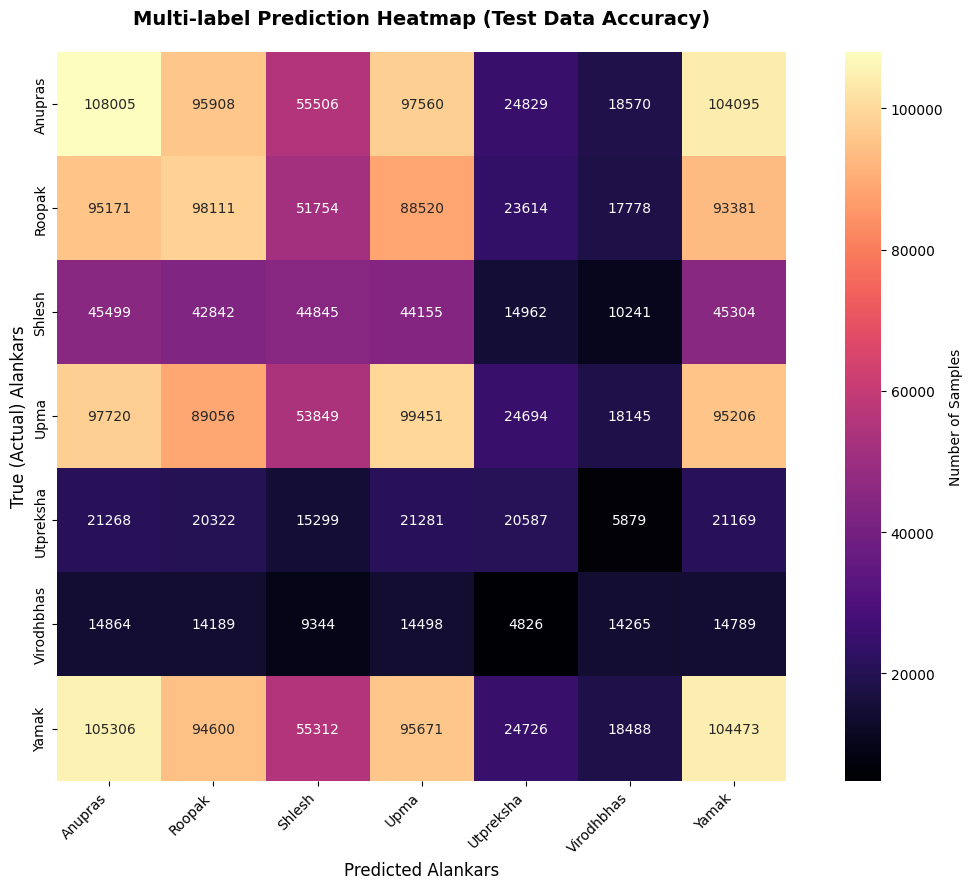

✅ Corrected heatmap using explicit intersection counts is complete.


In [14]:
y_true_arr = np.array(y_val)
y_pred_arr = (np.array(y_pred) >= THRESHOLD).astype(int)

multilabel_cm = np.zeros((num_classes, num_classes))

for i in range(num_classes):
    for j in range(num_classes):
        intersection = np.sum((y_true_arr[:, i] == 1) & (y_pred_arr[:, j] == 1))
        multilabel_cm[i, j] = intersection

plt.figure(figsize=(12, 9))
sns.heatmap(
    multilabel_cm,
    annot=True, fmt=".0f", cmap="magma",
    xticklabels=mlb.classes_, yticklabels=mlb.classes_,
    square=True, cbar_kws={"label": "Number of Samples"}
)
plt.title("Multi-label Prediction Heatmap (Test Data Accuracy)", fontsize=14, pad=20, fontweight='bold')
plt.xlabel("Predicted Alankars", fontsize=12)
plt.ylabel("True (Actual) Alankars", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(CFG["save_dir"], "corrected_test_heatmap.png"), dpi=300)
plt.show()
print("✅ Corrected heatmap using explicit intersection counts is complete.")

# 🔲 Cell 14 — Confusion Matrix Heatmaps (Per Label — Test Data)

Generating Confusion Matrix Heatmaps (based on test/validation data)...


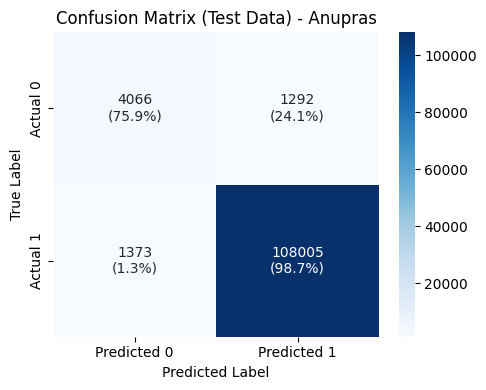

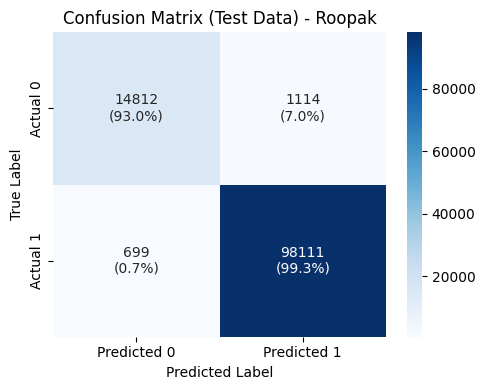

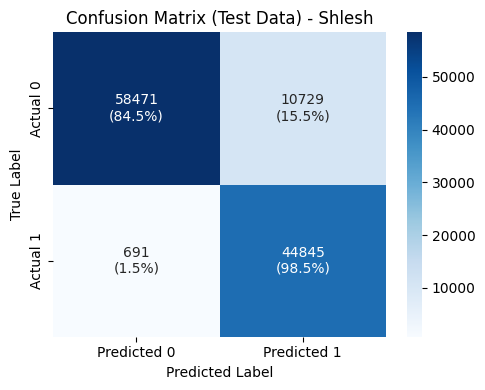

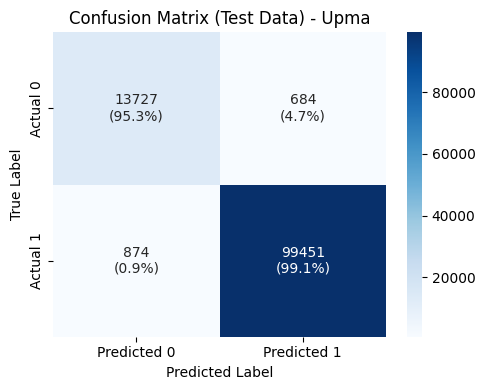

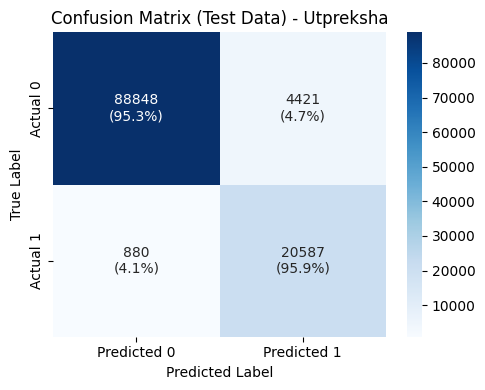

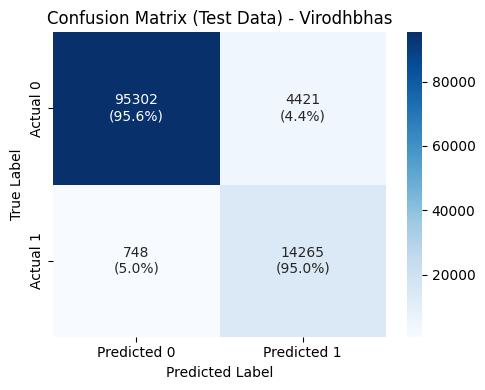

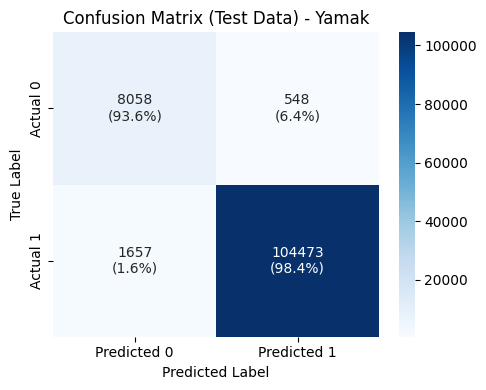

✅ Confusion matrices (test data) saved as PNG and CSV.


In [15]:
print("Generating Confusion Matrix Heatmaps (based on test/validation data)...")
conf_matrices = multilabel_confusion_matrix(y_val, y_pred)

for i, label in enumerate(mlb.classes_):
    cm    = conf_matrices[i]
    cm_df = pd.DataFrame(cm, index=["Actual 0", "Actual 1"],
                         columns=["Predicted 0", "Predicted 1"])
    csv_path = os.path.join(CFG["save_dir"], f"confusion_matrix_{label}.csv")
    cm_df.to_csv(csv_path)

    cm_sum  = cm.sum(axis=1, keepdims=True)
    cm_perc = np.divide(cm.astype(float), cm_sum, where=cm_sum != 0) * 100
    annot   = np.array([
        [f"{v}\n({cm_perc[r, c]:.1f}%)" for c, v in enumerate(row)]
        for r, row in enumerate(cm)
    ])

    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=annot, fmt="", cmap="Blues",
                xticklabels=["Predicted 0", "Predicted 1"],
                yticklabels=["Actual 0", "Actual 1"])
    plt.title(f"Confusion Matrix (Test Data) - {label}")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    png_path = os.path.join(CFG["save_dir"], f"confusion_matrix_{label}.png")
    plt.savefig(png_path, dpi=300)
    plt.show()

print("✅ Confusion matrices (test data) saved as PNG and CSV.")

# 📈 Cell 15 — Plot Training History (Accuracy & Loss)

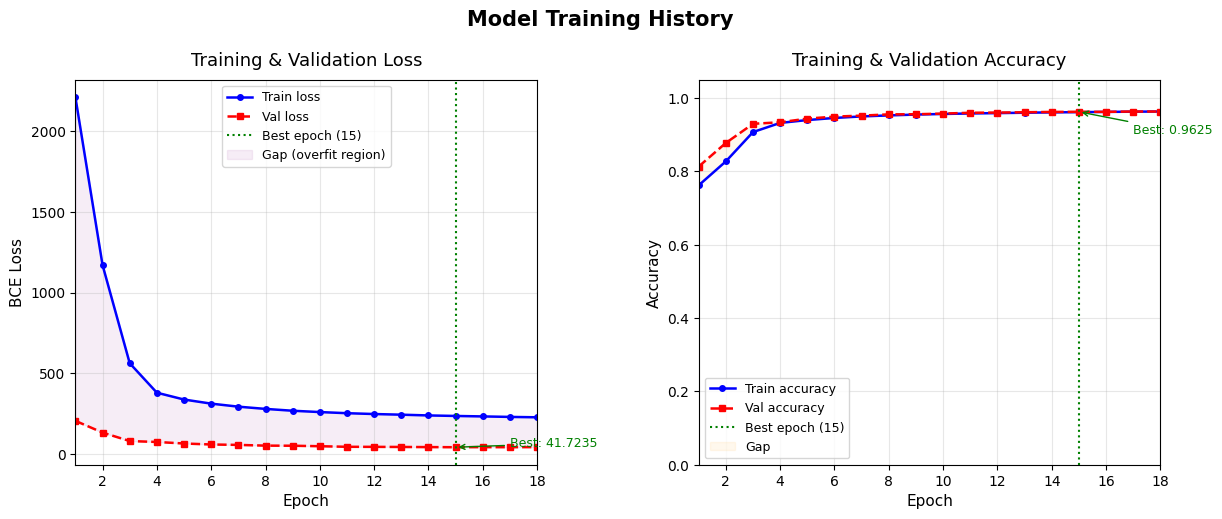

✅ Training history graphs saved.
   Best epoch        : 15
   Best val loss     : 41.7235
   Best val accuracy : 0.9625


In [16]:
import matplotlib.gridspec as gridspec

epochs_ran      = range(1, len(train_loss_hist) + 1)
best_epoch_idx  = int(np.argmin(val_loss_hist))

fig = plt.figure(figsize=(14, 5))
gs  = gridspec.GridSpec(1, 2, figure=fig, wspace=0.35)

ax1 = fig.add_subplot(gs[0])
ax1.plot(epochs_ran, train_loss_hist, 'b-o',  markersize=4, linewidth=1.8, label='Train loss')
ax1.plot(epochs_ran, val_loss_hist,   'r--s', markersize=4, linewidth=1.8, label='Val loss')
ax1.axvline(best_epoch_idx + 1, color='green', linestyle=':', linewidth=1.5,
            label=f'Best epoch ({best_epoch_idx + 1})')
ax1.fill_between(epochs_ran, train_loss_hist, val_loss_hist, alpha=0.07, color='purple',
                 label='Gap (overfit region)')
ax1.set_title('Training & Validation Loss', fontsize=13, pad=10)
ax1.set_xlabel('Epoch', fontsize=11)
ax1.set_ylabel('BCE Loss', fontsize=11)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(1, len(epochs_ran))

best_val_loss = val_loss_hist[best_epoch_idx]
ax1.annotate(f'Best: {best_val_loss:.4f}',
             xy=(best_epoch_idx + 1, best_val_loss),
             xytext=(best_epoch_idx + 1 + max(1, len(epochs_ran)//8), best_val_loss + 0.01),
             arrowprops=dict(arrowstyle='->', color='green'), fontsize=9, color='green')

ax2 = fig.add_subplot(gs[1])
ax2.plot(epochs_ran, train_acc_hist, 'b-o',  markersize=4, linewidth=1.8, label='Train accuracy')
ax2.plot(epochs_ran, val_acc_hist,   'r--s', markersize=4, linewidth=1.8, label='Val accuracy')
ax2.axvline(best_epoch_idx + 1, color='green', linestyle=':', linewidth=1.5,
            label=f'Best epoch ({best_epoch_idx + 1})')
ax2.fill_between(epochs_ran, train_acc_hist, val_acc_hist, alpha=0.07, color='orange', label='Gap')
ax2.set_title('Training & Validation Accuracy', fontsize=13, pad=10)
ax2.set_xlabel('Epoch', fontsize=11)
ax2.set_ylabel('Accuracy', fontsize=11)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.set_xlim(1, len(epochs_ran))
ax2.set_ylim(0, 1.05)

best_val_acc = val_acc_hist[best_epoch_idx]
ax2.annotate(f'Best: {best_val_acc:.4f}',
             xy=(best_epoch_idx + 1, best_val_acc),
             xytext=(best_epoch_idx + 1 + max(1, len(epochs_ran)//8), best_val_acc - 0.06),
             arrowprops=dict(arrowstyle='->', color='green'), fontsize=9, color='green')

plt.suptitle('Model Training History', fontsize=15, fontweight='bold', y=1.02)
plt.savefig(os.path.join(CFG["save_dir"], 'training_history.png'), dpi=300, bbox_inches='tight')
plt.show()

print("✅ Training history graphs saved.")
print(f"   Best epoch        : {best_epoch_idx + 1}")
print(f"   Best val loss     : {best_val_loss:.4f}")
print(f"   Best val accuracy : {best_val_acc:.4f}")

# ⏱ Cell 16 — Total Runtime & Output Summary

In [17]:
total_seconds = time.time() - training_start_time
hours   = int(total_seconds // 3600)
minutes = int((total_seconds % 3600) // 60)
seconds = int(total_seconds % 60)

with open(os.path.join(CFG["save_dir"], "runtime.txt"), "w") as f:
    f.write(f"{hours}h {minutes}m {seconds}s")

print("\n" + "="*50)
print(f"⏱  TOTAL RUNTIME: {hours}h {minutes}m {seconds}s")
print("="*50)
print("\n✅ All outputs saved to", CFG['save_dir'])
print("   - best_model.pt")
print("   - corrected_test_heatmap.png")
print("   - confusion_matrix_<label>.png / .csv")
print("   - training_history.png")
print("   - runtime.txt")


⏱  TOTAL RUNTIME: 4h 47m 49s

✅ All outputs saved to /kaggle/working/alankar_model
   - best_model.pt
   - corrected_test_heatmap.png
   - confusion_matrix_<label>.png / .csv
   - training_history.png
   - runtime.txt


# 🔮 Cell 17 — Test on Unseen Data
Run this AFTER the model training completes. Predict Alankars on new, unseen Hindi text.

In [18]:
import numpy as np
import pandas as pd

unseen_texts = [
    "उसका चेहरा चाँद जैसा उजाला है,",
    "मंद-मंद मुस्कान मन को भाया है,",
    "चंचल चितवन चुरा ले गई दिल को,",
    "उसकी बातें जैसे मधुर रस की धारा हैं,",
    "वह तो जीवन का सूरज बन आया है।"
]

enc = tokenizer(
    unseen_texts, padding=True, truncation=True,
    max_length=CFG["max_len"], return_tensors="pt"
)

input_ids_unseen      = enc["input_ids"].to(DEVICE)
attention_mask_unseen = enc["attention_mask"].to(DEVICE)

model.eval()
with torch.inference_mode():
    with torch.cuda.amp.autocast():
        logits_unseen = model(input_ids_unseen, attention_mask_unseen)
    proba_unseen  = torch.sigmoid(logits_unseen).cpu().numpy()

y_pred_unseen = (proba_unseen >= THRESHOLD).astype(int)

print("\n" + "="*70)
print(" "*15 + "UNSEEN DATA — ALANKAR PREDICTIONS")
print("="*70)

for i, text in enumerate(unseen_texts):
    detected = [mlb.classes_[j] for j in range(len(mlb.classes_)) if y_pred_unseen[i][j] == 1]
    print(f"\n📝 Text     : {text}")
    print(f"🎯 Alankars : {detected if detected else ['None detected']}")
    prob_str = " | ".join(
        [f"{mlb.classes_[j]}: {proba_unseen[i][j]:.3f}" for j in range(len(mlb.classes_))]
    )
    print(f"📊 Proba    : {prob_str}")

print("\n" + "="*70)

results_df = pd.DataFrame({
    "Text": unseen_texts,
    "Predicted Alankars": [
        ", ".join([mlb.classes_[j] for j in range(len(mlb.classes_)) if y_pred_unseen[i][j] == 1]) or "None"
        for i in range(len(unseen_texts))
    ]
})

for j, cls in enumerate(mlb.classes_):
    results_df[f"P({cls})"] = [round(float(proba_unseen[i][j]), 4) for i in range(len(unseen_texts))]

output_path = os.path.join(CFG["save_dir"], "unseen_predictions.xlsx")
results_df.to_excel(output_path, index=False)
print(f"\n✅ Predictions saved to: {output_path}")
print("\n" + results_df[["Text", "Predicted Alankars"]].to_string(index=False))


               UNSEEN DATA — ALANKAR PREDICTIONS

📝 Text     : उसका चेहरा चाँद जैसा उजाला है,
🎯 Alankars : ['Roopak', 'Upma']
📊 Proba    : Anupras: 0.094 | Roopak: 0.998 | Shlesh: 0.000 | Upma: 0.984 | Utpreksha: 0.002 | Virodhbhas: 0.005 | Yamak: 0.007

📝 Text     : मंद-मंद मुस्कान मन को भाया है,
🎯 Alankars : ['Anupras', 'Roopak', 'Shlesh']
📊 Proba    : Anupras: 0.590 | Roopak: 0.999 | Shlesh: 0.642 | Upma: 0.011 | Utpreksha: 0.000 | Virodhbhas: 0.000 | Yamak: 0.010

📝 Text     : चंचल चितवन चुरा ले गई दिल को,
🎯 Alankars : ['Anupras']
📊 Proba    : Anupras: 0.676 | Roopak: 0.004 | Shlesh: 0.001 | Upma: 0.002 | Utpreksha: 0.000 | Virodhbhas: 0.000 | Yamak: 0.115

📝 Text     : उसकी बातें जैसे मधुर रस की धारा हैं,
🎯 Alankars : ['Roopak', 'Upma', 'Utpreksha']
📊 Proba    : Anupras: 0.236 | Roopak: 0.993 | Shlesh: 0.027 | Upma: 0.998 | Utpreksha: 0.994 | Virodhbhas: 0.000 | Yamak: 0.005

📝 Text     : वह तो जीवन का सूरज बन आया है।
🎯 Alankars : ['Roopak']
📊 Proba    : Anupras: 0.065 | Roopak: 

/tmp/ipykernel_57/1359702585.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
